<img src="assets/DemoSlidesForExport_0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/perturbation0.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />




<img src="assets/perturbation1.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/perturbation2.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<img src="assets/perturbation3.png" alt="" style="max-width: 100%; max-height: 88vh; width: auto; height: auto; object-fit: contain; display: block; margin: 0 auto;" />

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box; align=center;">
<img src="assets/image79.gif" alt="" style="max-width: 40%; max-height: 88vh; width: auto; height: auto;margin: 0 auto;" /><img src="assets/image83.gif" alt="" style="max-width: 40%; max-height: 88vh; width: auto; height: auto; margin: 0 auto;" />
</div>

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Initialization</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star consists of python packages that are installable via <code>pip</code> — the standard Python package installer.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>
</div>

In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
from IPython.display import Markdown, display

import cstar_forge
import roms_tools as rt

env = cstar_forge.config.get_environment_info()

# Display summary
summary = f"""
### Machine Information
- **Hostname**: `{env.hostname}`
- **System Tag**: `{env.system_tag}`
- **OS**: `{env.os_info}`

### Environment Summary
- **Python Version**: `{env.python_version}`
- **Python Executable**: `{env.python_executable}`
- **Conda/Micromamba Environment**: `{env.env_info}`
- **Kernel**: `{env.kernel_spec}`
"""

display(Markdown(summary))
print(f"C-Star imported: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



### Machine Information
- **Hostname**: `hoatzin`
- **System Tag**: `MacOS`
- **OS**: `Darwin 25.4.0 (arm64)`

### Environment Summary
- **Python Version**: `3.13.13`
- **Python Executable**: `/Users/blsaenz/miniforge3/envs/cworthy-test/bin/python`
- **Conda/Micromamba Environment**: `cworthy-test (/Users/blsaenz/miniforge3/envs/cworthy-test)`
- **Kernel**: `unknown`


C-Star imported: 2026-05-21 17:18:12


<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Develop CDR forcing</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
A CDR intervention can be planned and built by C-star. Here we add the requirements to the CStarSpecBuilder to create modified blueprints and ROMS-MARBL input files in order to add alkalinity (at a location, details on amount): </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Maybe details here, showing code chages.</p>
</div>

In [11]:
# make CDR forcing
start_time = datetime(2010, 1, 1)
end_time = datetime(2010, 1, 31)

times = [datetime(2010, 1, 1, 0),
           datetime(2010, 1, 2, 0),
           datetime(2010, 1, 31, 0),
          ]

volume_fluxes = [0, 100, 500] # m3/s
tracer_fluxes = {"ALK": [0.0, 60.0*10**6, 60.0*10**6]} # meq/s
tracer_concentrations = {
    "ALK": [1900.0, 2100.0, 1900.0],  # meq/m3
    "temp": 20.0,  # degrees C
    "salt": 1.0,  # psu
}

cdr_tracer_release1 = rt.TracerPerturbation(
name="release_1",
    lat=59.64,  # degree N
    lon=211.12,  # degree E
    depth=2,  # m
    hsc=500,
    vsc=300,
    times=times,
    tracer_fluxes=tracer_fluxes
)

cdr_volume_release1 = rt.VolumeRelease(
    name="v_release1",
    lat=57.88,  # degree N
    lon=360.-151.67,  # degree E
    depth=2,  # m
    times=times,
    volume_fluxes=volume_fluxes,
    tracer_concentrations=tracer_concentrations,
)

print("CDR options loaded.\n")

CDR options loaded.



<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Define model grid</h1>
    <p style="font-size: large; line-height: 1.45; margin: 0;">
Here we name and define a ROMS model grid using named parameters, grouped into 'settings' and 'boundaries'.
    <p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
These python objects will be used in the next step to establish CStarSpeBuilder, which will be used to complete C-Star setup.
    </p>
</div>

<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Define the dimensions that will build a ROMS model grid with plain-language names:
</p>

In [12]:
# Grid parameters ------------------------------------------------------------------
grid_name = "Gulf_of_Alaska_sm"
grid_settings = dict[str, float](
    # nx=208,              # X-direction grid cells (xi)
    # ny=192,              # Y-direction grid cells (eta)
    nx=160, #;320,              # X-direction grid cells (xi)
    ny=80, #160,              # Y-direction grid cells (eta)
    size_x=1460,         # km (longitude direction at ~49N)
    size_y=700,         # km (latitude direction)
    #center_lon=-139.5,   
    #center_lat=53,
    center_lon=-150.0,   
    center_lat=57.5,
    rot=41,              # rotation of grid (degrees)
    N=10,                # number of vertical levels
    #N=50,                # number of vertical levels
    theta_s=6.0,         # surface control parameter
    theta_b=3.0,         # bottom control parameter
    hc=250.0,            # critical depth
    #close_narrow_channels=True,
)
boundaries = {
        "south": True,
        "east": False,
        "north": True,
        "west": True, 
}
print("\nGrid options loaded.\n")


Grid options loaded.



<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Generate the full CDR forcing and plot:
</p>

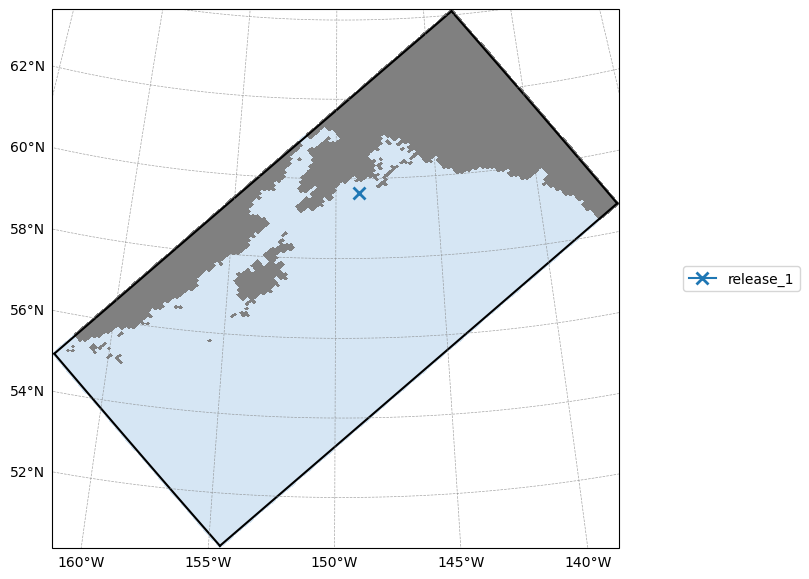

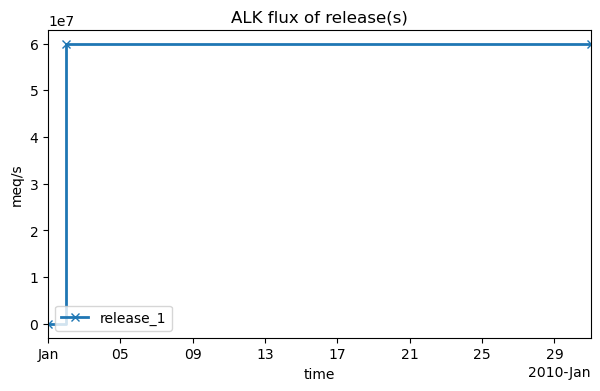

In [13]:
cdr = rt.CDRForcing(
    grid=rt.Grid(**grid_settings), # for plotting, could omit
    start_time=start_time,
    end_time=end_time,
    releases=[cdr_tracer_release1,],
)

cdr.plot_locations()
#cdr.plot_distribution("my_cdr")
cdr.plot_tracer_flux("ALK")

# Pass the cdr information as a dict, for now:
cdr_as_dict = cdr.model_dump()["CDRForcing"]

<p style="font-size: large; line-height: 1.45; margin: 0;">
Next we define a test model, using a pre-defined ROMS-MARBL model specification (a <b>model_spec</b>, which contains settings to enable ROMS-MARBL features and compilation to match your inputs and environment -- see models.yml for definition), and start and end dates.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
These changeable options are passed to the CstarSpecBuilder() object, which will find and generate the <b>forcing data</b>, and <b>C-Star blueprints</b> which will run the ROMS model and ensure <b>scientific reproducability<b>:
</p>

CstarSpecBuilder: planned NetCDF outputs
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_grid.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_initial_conditions.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_surface-physics.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_surface-bgc.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_surface-restoring.nc
  - /Users/blsaenz/cstar-forge-data/input-data/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs/cson_roms-marbl_v0_1_Gulf_of_Alaska_sm_4procs_boundary-physics.nc
  - /Users/blsaenz/c

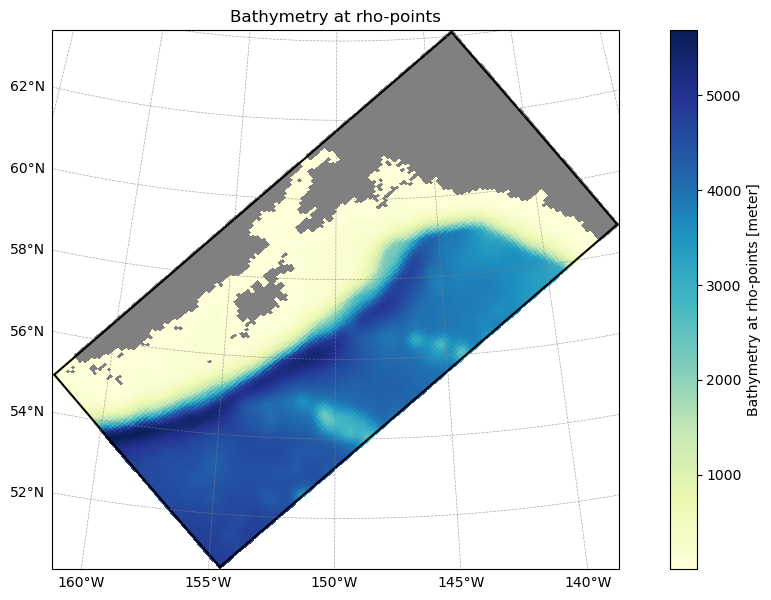

In [14]:
#Change to roms-tools grid gen, for plotting

# Model setup ------------------------------------------------------------------
model_spec = "cson_roms-marbl_v0.1"

partitioning = {
    "n_procs_x": 2, # number of partitions in xi (x) 
    "n_procs_y": 2, # number of partitions in eta (y) 
}

# Initialize CstarSpecBuilder --------------------------------------------------
ocn = cstar_forge.CstarSpecBuilder(
    description="GulfOfAlaska_sm",
    model_name=model_spec,
    grid_name=grid_name,
    grid_kwargs=grid_settings,
    open_boundaries=boundaries,    
    start_time=start_time,
    end_time=end_time,
    partitioning=partitioning,
    CDR_forcing=cdr_as_dict,
    #catalog_root = "local"
)

ocn.grid.plot()

Possibilities:  Change grid rotation.  

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star Forcing Data and Blueprint Generation</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
C-Star uses online, published datasets for ocean bathymetry, atmospheric variables, and initial and boundary conditions. These datasets are either steamable directly to C-Star or are staged online by C-Worthy. Data sources are specified in the 
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Carbon-accounting coastal model simulations and analysis can be run using imported python objects.
</p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Begin by importing python package(s), and checking the environment:
</p>

In [ ]:
#%%prun
#%load_ext line_profiler
# ensure that source data is staged locally
ocn.ensure_source_data()

# prepare model input
#%lprun -f ocn.generate_inputs(clobber=False) # setting clobber=True will overwrite existing files
ocn.generate_inputs(clobber=False) # setting clobber=True will overwrite existing files

# configure and build the model blueprints
ocn.configure_build(
    compile_time_settings={
        # "cdr_output": {
        #    "do_cdr": True
        # }
    }, 
    run_time_settings = {}
    #     "roms.in": {
    #         "time_stepping": {
    #             "dt": 900,
    #         }
    #     }
    # }
)

✔️  Using existing GLORYS_REGIONAL file for 2009-12-31: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20091231.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-01: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100101.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-02: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100102.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-03: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100103.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-04: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100104.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-05: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100105.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-06: cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100106.nc
✔️  Using existing GLORYS_REGIONAL file for 2010-01-07: cmems_mod_glo_phy_my_0.083d

INFO - 2026-05-22T02:40:07Z - Selected dataset version: "202311"
INFO - 2026-05-22T02:40:07Z - Selected dataset part: "default"
INFO - 2026-05-22T02:40:13Z - Starting download. Please wait...


  0%|          | 0/94 [00:00<?, ?it/s]

2026-05-22 02:40:34,796 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:40:34,911 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:40:35,218 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:40:35,293 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:40:35,397 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:40:35,413 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
INFO - 2026-05-22T02:40:35Z - Successfully dow

⬇️  Downloading GLORYS_REGIONAL for 2010-01-13 → cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100113.nc


...

  0%|          | 0/94 [00:00<?, ?it/s]

2026-05-22 02:45:16,673 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:45:16,681 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:45:16,684 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:45:16,751 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:45:16,786 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
2026-05-22 02:45:16,793 [WARNING] - connectionpool.py:327 - Connection pool is full, discarding connection: s3.waw3-1.cloudferro.com. Connection pool size: 10
INFO - 2026-05-22T02:45:16Z - Successfully dow

⬇️  Downloading GLORYS_REGIONAL for 2010-01-22 → cmems_mod_glo_phy_my_0.083deg_P1D-m_REGIONAL_Gulf_of_Alaska_sm_20100122.nc


INFO - 2026-05-22T02:45:20Z - Selected dataset version: "202311"
INFO - 2026-05-22T02:45:20Z - Selected dataset part: "default"
INFO - 2026-05-22T02:45:26Z - Starting download. Please wait...


  0%|          | 0/94 [00:00<?, ?it/s]

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Run ROMS-MARBL from Blueprint</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
Core C-Star functionality, like running a blueprint, is grouped into high-level commands </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

In [9]:
%%time



ocn.prep_cstar_environment(
   account_key = None,  # None gets from machine config or override here
   queue_name = None,  # None gets from machine config or override here
   walltime = "02:00:00",
   clobber = True,  # recommend True, but it will clear previous results from this run
   n_procs_available = 4,  # 0 is auto-detect, change if on a login or shared node to not overuse resources
)

import os
os.environ["THIS_BP_PATH"] = str(ocn.path_blueprint(stage="build"))

!echo $THIS_BP_PATH
!cstar blueprint run $THIS_BP_PATH

# not working
#await ocn.run()


/Users/blsaenz/cstar-forge-data/catalog/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs/B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs_build.yml
2026-05-21 17:28:28,072 [INFO] - simulation.py:1288 - 🛠️ Configuring ROMSSimulation
2026-05-21 17:28:28,072 [INFO] - simulation.py:1291 - 🔧 Setting up ROMSExternalCodeBase...
2026-05-21 17:28:42,204 [INFO] - simulation.py:1291 - 🔧 Setting up MARBLExternalCodeBase...
2026-05-21 17:29:00,051 [INFO] - simulation.py:1305 - 📦 Fetching compile-time code...
2026-05-21 17:29:00,060 [INFO] - simulation.py:1310 - 📦 Fetching runtime code... 
2026-05-21 17:29:00,062 [INFO] - simulation.py:1315 - 📦 Fetching input datasets...
2026-05-21 17:29:00,087 [INFO] - input_dataset.py:97 - 🔗 Created symlink: /Users/blsaenz/cstar-forge-data/cstar-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs_20100101-20100110/work/cdr.nc → /Users/blsaenz/cstar-forge-data/cstar-forge-run/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_4procs_20100101-20100110/input/inp

Alternate CStar-Forge ROMS-MARBL build and compute methods, using the preferred way of running via the C-Star CLI (command line interface).

In [ ]:


%%time
#target_dir = "/Users/blsaenz/Projects/git/cson-forge/cson_forge/blueprints/MacOS/cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs"
#%cd $target_dir

#!zsh -c "cstar blueprint check B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml"

#!zsh -c 'cstar blueprint run B_cson_roms-marbl_v0.1_Gulf_of_Alaska_sm_8procs_build.yml --clobber'
# !zsh -c 'export DYLD_FALLBACK_LIBRARY_PATH="/opt/homebrew/opt/netcdf/lib:/opt/homebrew/opt/netcdf-fortran/lib:$DYLD_FALLBACK_LIBRARY_PATH" && cstar blueprint run B_cson_roms-marbl_v0.1_Gulf_of_Alaska_8procs_build.yml --clobber'

# Run C-Star via CLI
# This is recommended in order to get people used to using the CLI for these operations

import os
os.environ["THIS_BP_PATH"] = str(ocn.path_blueprint(stage="build"))

!echo $THIS_BP_PATH
!cstar blueprint run $THIS_BP_PATH

<div style="background-color: #b8cde0; padding: 30px; min-height: 80vh; width: 100%; box-sizing: border-box;">
<h1 style="margin: 0 0 0.8rem 0; font-size: clamp(1.4rem, 3vw, 2.2rem);">C-Star: Analyze ROMS_MARBL output</h1>
<p style="font-size: large; line-height: 1.45; margin: 0;">
After blueprint or workplan execution finishes, modeled results can be examined and summaried using ROMS-Tools </p><br>
<p style="font-size: large; line-height: 1.45; max-width: 52rem; margin: 0;">
Here we check the blueprint produced in the previous steps, and then compile and ROMS-MARBL and follow the blueprint to perform a model integration.</p>
</div>

First, Last output times:  2010-01-01 01:07:30 2010-01-10 00:00:00
DatetimeIndex(['2010-01-01 01:07:30', '2010-01-01 02:15:00',
               '2010-01-01 03:22:30', '2010-01-01 04:30:00',
               '2010-01-01 05:37:30', '2010-01-01 06:45:00',
               '2010-01-01 07:52:30', '2010-01-01 09:00:00',
               '2010-01-01 10:07:30', '2010-01-01 11:15:00',
               ...
               '2010-01-09 13:52:30', '2010-01-09 15:00:00',
               '2010-01-09 16:07:30', '2010-01-09 17:15:00',
               '2010-01-09 18:22:30', '2010-01-09 19:30:00',
               '2010-01-09 20:37:30', '2010-01-09 21:45:00',
               '2010-01-09 22:52:30', '2010-01-10 00:00:00'],
              dtype='datetime64[ns]', length=192, freq=None)
[########################################] | 100% Completed | 106.98 ms
[########################################] | 100% Completed | 113.93 ms
[########################################] | 100% Completed | 106.26 ms
[#########################

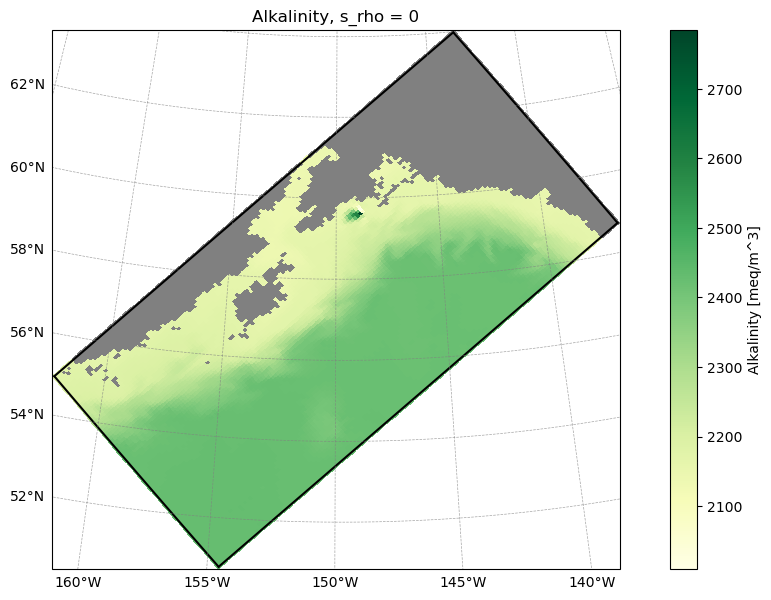

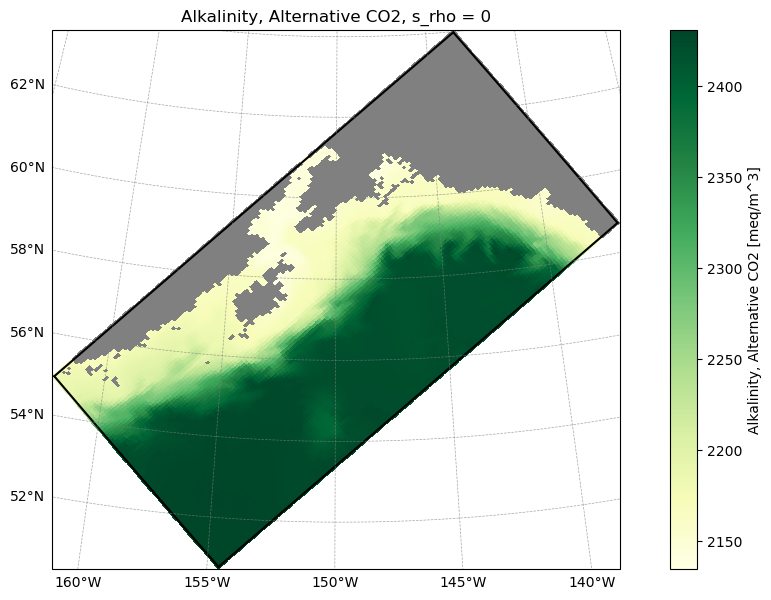

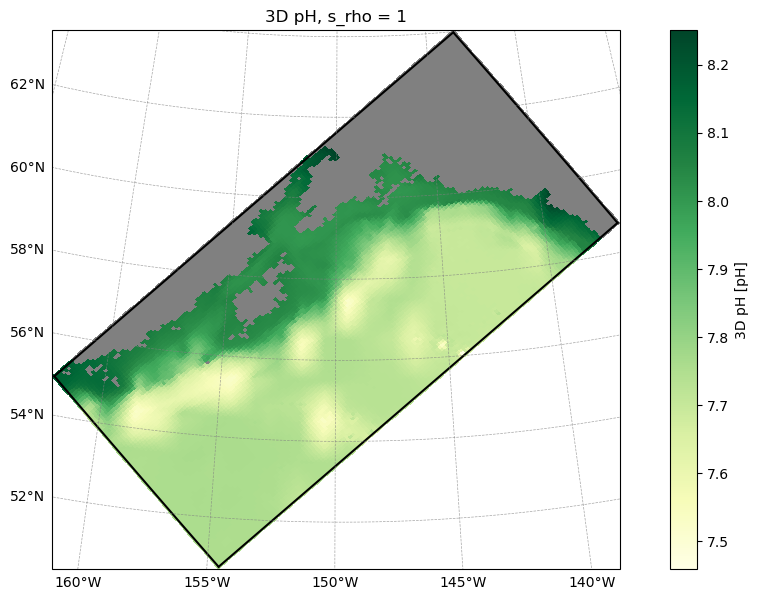

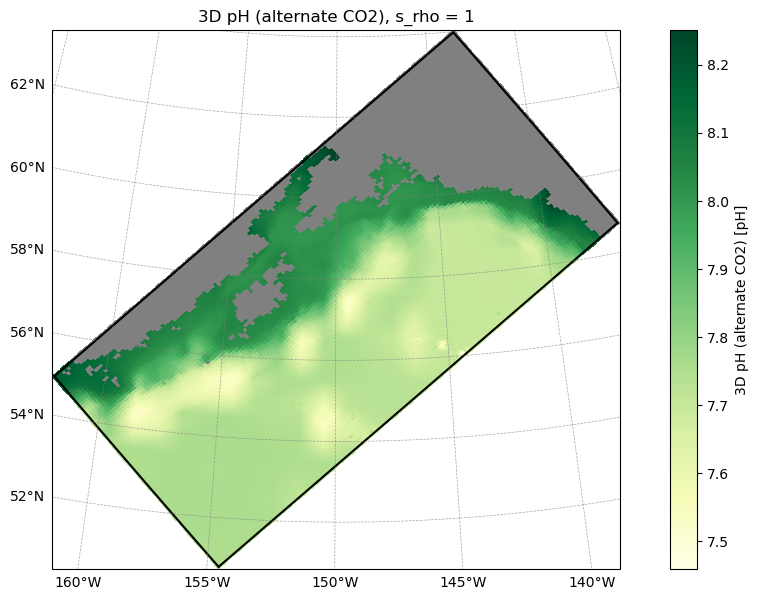

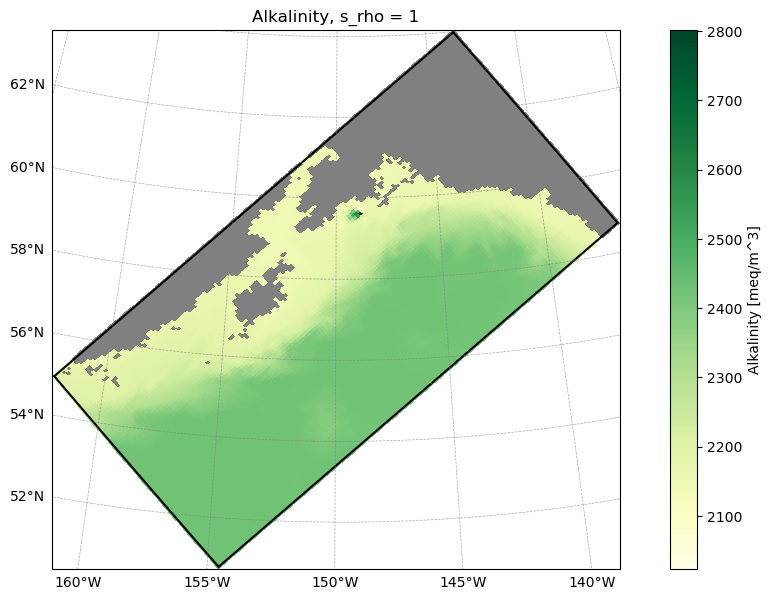

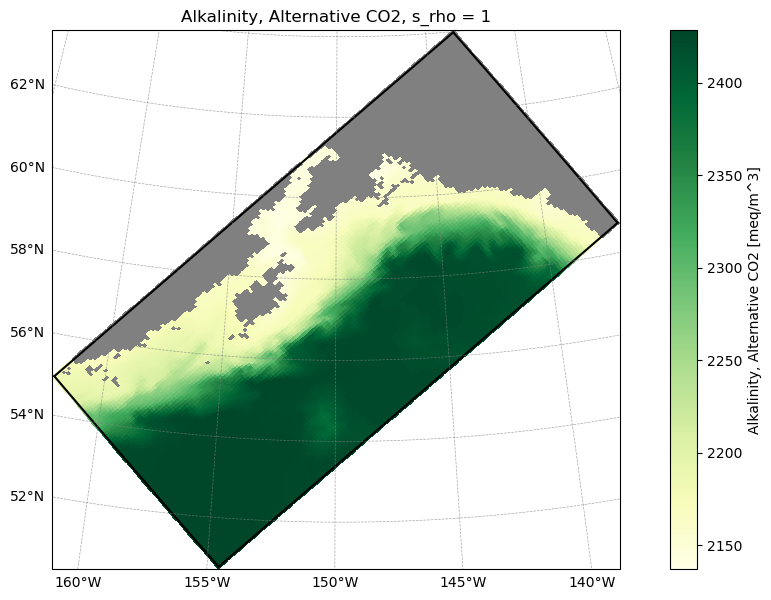

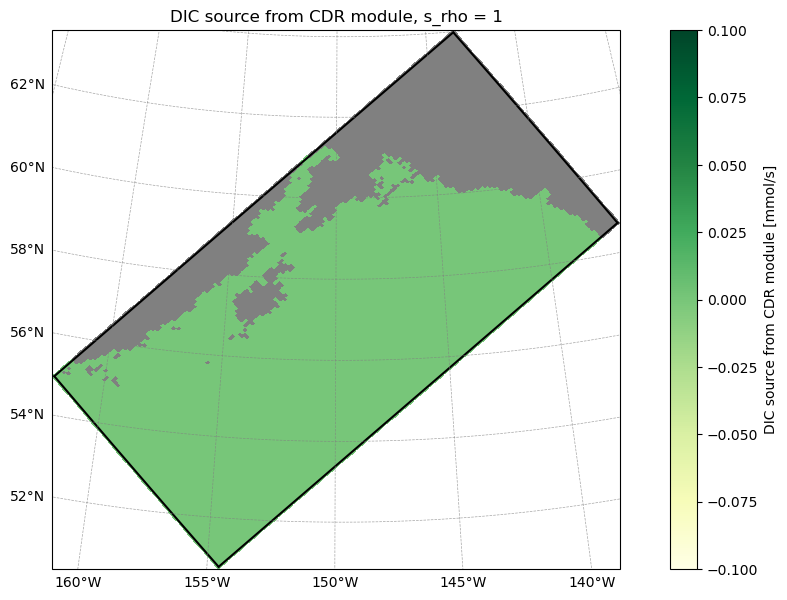

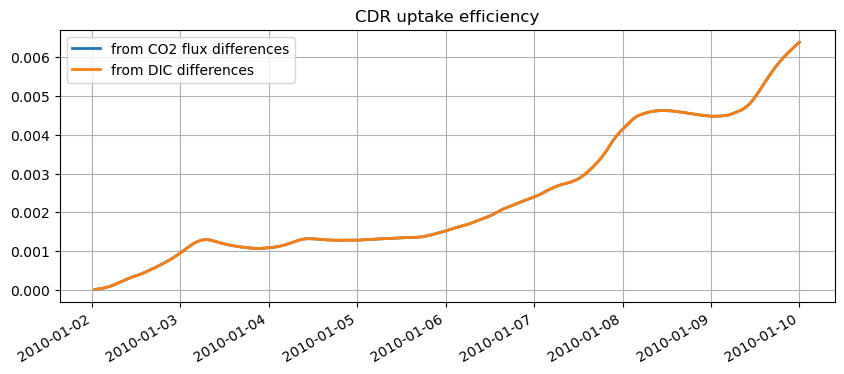

In [ ]:
import pandas as pd
#import os,glob


#grid = Grid.from_file(os.path.join(run,"input","input_datasets","cson_roms-marbl_v0_1_Gulf_of_Alaska_8procs_grid.nc"))
roms_output = rt.ROMSOutput(grid=ocn.grid, path=ocn.run_output_dir / "joined_output" / "output_cdr.*.nc", use_dask=True)
rst_output = rt.ROMSOutput(grid=ocn.grid, path=ocn.run_output_dir / "joined_output" / "output_rst.*.nc", use_dask=True)

time_index = pd.DatetimeIndex(roms_output.ds.time.values)
print('First, Last output times: ',time_index[0],time_index[-1])
print(time_index)
#print(roms_output.ds.time)
roms_output.plot("ALK", time=5*24, s=0)
roms_output.plot("ALK_ALT_CO2", time=5*24, s=0)
roms_output.plot("pH", time=9, s=1)
roms_output.plot("pH_ALT_CO2", time=9, s=1)
rst_output.plot("ALK", time=9, s=1)
rst_output.plot("ALK_ALT_CO2", time=9, s=1)
roms_output.plot("DIC_source", time=4, s=1)
roms_output.cdr_metrics()